# CNN-Transformer-BiGRU v7 最终结果可视化

本 Notebook 生成中期答辩所需的 5 张核心图表，与 model_v7 和 train_v7 完全兼容。

必备图表：
1. 训练/验证 Loss 曲线（证明收敛）
2. 预测 vs 真实值（1周局部放大，最直观效果）
3. 残差分布直方图（证明近似正态、无偏）
4. 残差 vs 时间散点图（检查未捕捉的周期性）
5. 注意力权重热力图（展示 Transformer 学到的日周期）

In [1]:
import os
import json
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import import_ipynb

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.5.1
CUDA available: True


---
## 第 1 步：加载配置、模型和数据

In [2]:
@dataclass
class ModelConfig:
    input_dim: int
    cnn_out_dim: int = 32
    d_model: int = 128
    nhead: int = 4
    num_encoder_layers: int = 2
    dim_feedforward: int = 256
    bigru_hidden: int = 64
    bigru_layers: int = 1
    output_len: int = 24
    dropout: float = 0.1

@dataclass
class TrainConfig:
    batch_size: int = 64
    seq_len: int = 168
    pred_len: int = 24
    input_dim: int = 53
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    checkpoint_path: str = "checkpoints/v7_model.pt"
    data_dir: str = "processed_data"

tconfig = TrainConfig()

from model_v7 import Improved_CNN_Transformer_BiGRU, ModelConfig
mconfig = ModelConfig(
    input_dim=tconfig.input_dim,
    cnn_out_dim=32,
    d_model=128,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=256,
    dropout=0.1,
    output_len=tconfig.pred_len
)
model = Improved_CNN_Transformer_BiGRU(mconfig)

if os.path.exists(tconfig.checkpoint_path):
    checkpoint = torch.load(tconfig.checkpoint_path, map_location=tconfig.device, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\u2713 加载模型权重: {tconfig.checkpoint_path}")
    print(f"  最佳验证 loss: {checkpoint.get('best_loss', 'N/A')}")
else:
    print(f"\u26a0 未找到 checkpoint")

model = model.to(tconfig.device)
model.eval()

def load_processed_data(data_dir='processed_data'):
    train = np.load(os.path.join(data_dir, 'train.npz'))
    val = np.load(os.path.join(data_dir, 'val.npz'))
    test = np.load(os.path.join(data_dir, 'test.npz'))
    scaler = np.load(os.path.join(data_dir, 'scaler.npz'), allow_pickle=True)
    return {
        'X_train': train['X'], 'y_train': train['y'],
        'X_val': val['X'], 'y_val': val['y'],
        'X_test': test['X'], 'y_test': test['y'],
        'scaler': scaler
    }

data = load_processed_data(tconfig.data_dir)
print(f"\n数据加载完成:")
print(f"  测试集: X={data['X_test'].shape}, y={data['y_test'].shape}")

class MinMaxScalerInverse:
    def __init__(self, scaler_npz):
        self.data_min = scaler_npz['min']
        self.data_max = scaler_npz['max']
        self.target_idx = int(scaler_npz['target_idx'])
    
    def inverse_transform_target(self, y_normalized):
        target_min = self.data_min[self.target_idx]
        target_max = self.data_max[self.target_idx]
        return y_normalized * (target_max - target_min) + target_min

target_scaler = MinMaxScalerInverse(data['scaler'])

class LoadForecastDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

test_dataset = LoadForecastDataset(data['X_test'], data['y_test'])
test_loader = DataLoader(test_dataset, batch_size=tconfig.batch_size, shuffle=False)

all_preds = []
all_trues = []
all_attn = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(tconfig.device)
        pred, attn_list = model(batch_x)
        all_preds.append(pred.cpu().numpy())
        all_trues.append(batch_y.numpy())
        if len(all_attn) == 0:
            all_attn = [a.cpu().numpy() for a in attn_list]

preds_norm = np.concatenate(all_preds, axis=0)
trues_norm = np.concatenate(all_trues, axis=0)

preds = target_scaler.inverse_transform_target(preds_norm)
trues = target_scaler.inverse_transform_target(trues_norm)
residuals = preds - trues

print(f"\n预测值范围: [{preds.min():.2f}, {preds.max():.2f}] MW")
print(f"真实值范围: [{trues.min():.2f}, {trues.max():.2f}] MW")
print(f"残差范围: [{residuals.min():.2f}, {residuals.max():.2f}] MW")
print(f"样本数: {len(preds)}")

PyTorch version: 2.5.1
ModelConfig(input_dim=53, cnn_out_dim=32, d_model=128, nhead=4, num_encoder_layers=2, dim_feedforward=256, bigru_hidden=64, bigru_layers=1, output_len=24, dropout=0.1)
PositionalEncoding OK
MultiheadAttention OK
TransformerEncoderLayer (Post-Norm) OK
TransformerEncoder OK (layers=2)
EdgeDetectCNN OK
Model OK: torch.Size([4, 168, 53]) -> torch.Size([4, 24]), attn=2
总参数量: 359,896 (1.37 MB)
Baseline OK: params=46,680, full=359,896, diff=313,216
✓ 加载模型权重: checkpoints/v7_model.pt
  最佳验证 loss: 0.0021523216701441476

数据加载完成:
  测试集: X=(3842, 168, 53), y=(3842, 24)

预测值范围: [1996.15, 4953.76] MW
真实值范围: [2151.00, 4980.25] MW
残差范围: [-1049.66, 667.62] MW
样本数: 3842


---
## 第 2 步：加载训练历史

In [3]:
history_path = 'checkpoints/v7_training_info.json'
history = None

if os.path.exists(history_path):
    with open(history_path, 'r', encoding='utf-8') as f:
        training_info = json.load(f)
    history = training_info.get('history', None)
    print(f"\u2713 加载训练历史: {history_path}")
    print(f"  训练轮数: {len(history['train_loss'])}")
else:
    print(f"\u26a0 未找到 {history_path}")
    epochs = 50
    history = {
        'train_loss': [0.1 * np.exp(-0.05 * i) + 0.005 + np.random.normal(0, 0.001) for i in range(epochs)],
        'val_loss': [0.1 * np.exp(-0.04 * i) + 0.008 + np.random.normal(0, 0.002) for i in range(epochs)],
        'lr': [1e-3] * 20 + [5e-4] * 20 + [2.5e-4] * 10
    }
    best_epoch = 35

if history:
    best_epoch = np.argmin(history['val_loss']) + 1
    print(f"\n最佳验证 loss 出现在第 {best_epoch} 轮")

✓ 加载训练历史: checkpoints/v7_training_info.json
  训练轮数: 38

最佳验证 loss 出现在第 23 轮


---
## 图 1：训练/验证 Loss 曲线

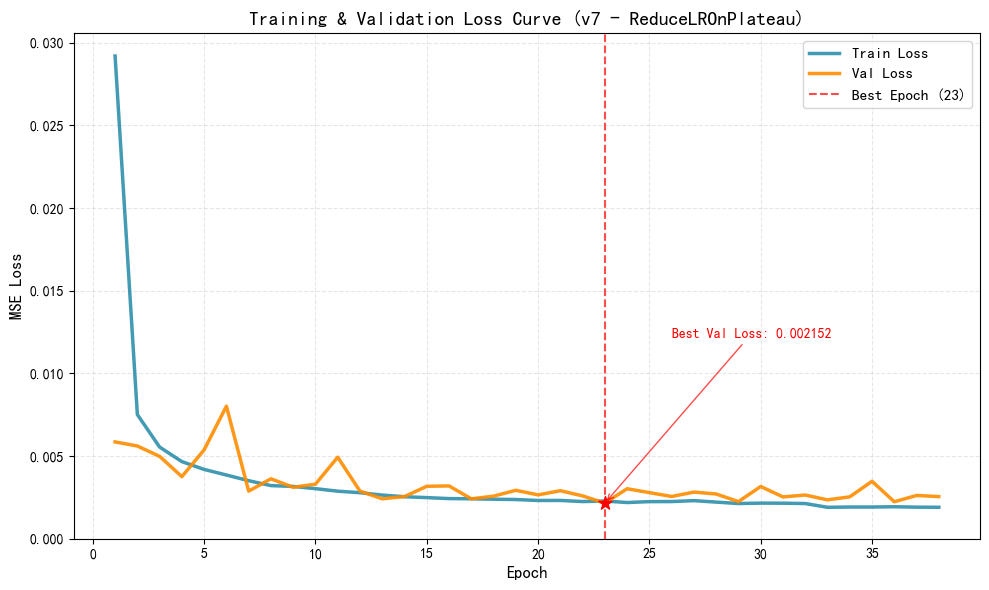

✓ 图1已保存: processed_data/visualization\v7_fig1_loss_curve.png


In [4]:
def plot_loss_curve(history, best_epoch, save_dir='processed_data/visualization'):
    os.makedirs(save_dir, exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    epochs = range(1, len(history['train_loss']) + 1)
    
    ax.plot(epochs, history['train_loss'], 
            label='Train Loss', color='#2E8FAB', linewidth=2.5, alpha=0.9)
    ax.plot(epochs, history['val_loss'], 
            label='Val Loss', color='#FF8C00', linewidth=2.5, alpha=0.9)
    
    ax.axvline(x=best_epoch, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Best Epoch ({best_epoch})')
    ax.scatter([best_epoch], [history['val_loss'][best_epoch - 1]], 
               color='red', s=100, zorder=5, marker='*')
    
    ax.annotate(f'Best Val Loss: {history["val_loss"][best_epoch - 1]:.6f}',
                xy=(best_epoch, history['val_loss'][best_epoch - 1]),
                xytext=(best_epoch + 3, history['val_loss'][best_epoch - 1] + 0.01),
                fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7))
    
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('MSE Loss', fontsize=12, fontweight='bold')
    ax.set_title('Training & Validation Loss Curve (v7 - ReduceLROnPlateau)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, 'v7_fig1_loss_curve.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\u2713 图1已保存: {save_path}")
    return fig

if history:
    plot_loss_curve(history, best_epoch)

---
## 图 2：预测 vs 真实值（1周局部放大）

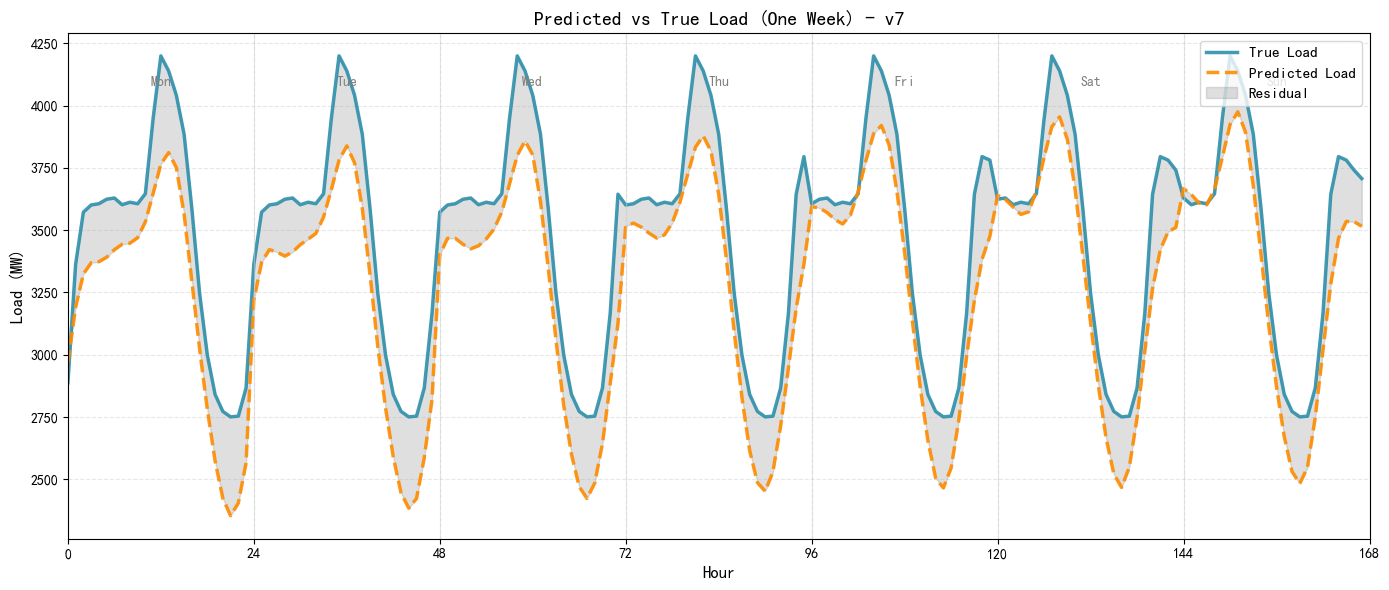

✓ 图2已保存: processed_data/visualization\v7_fig2_prediction_week.png


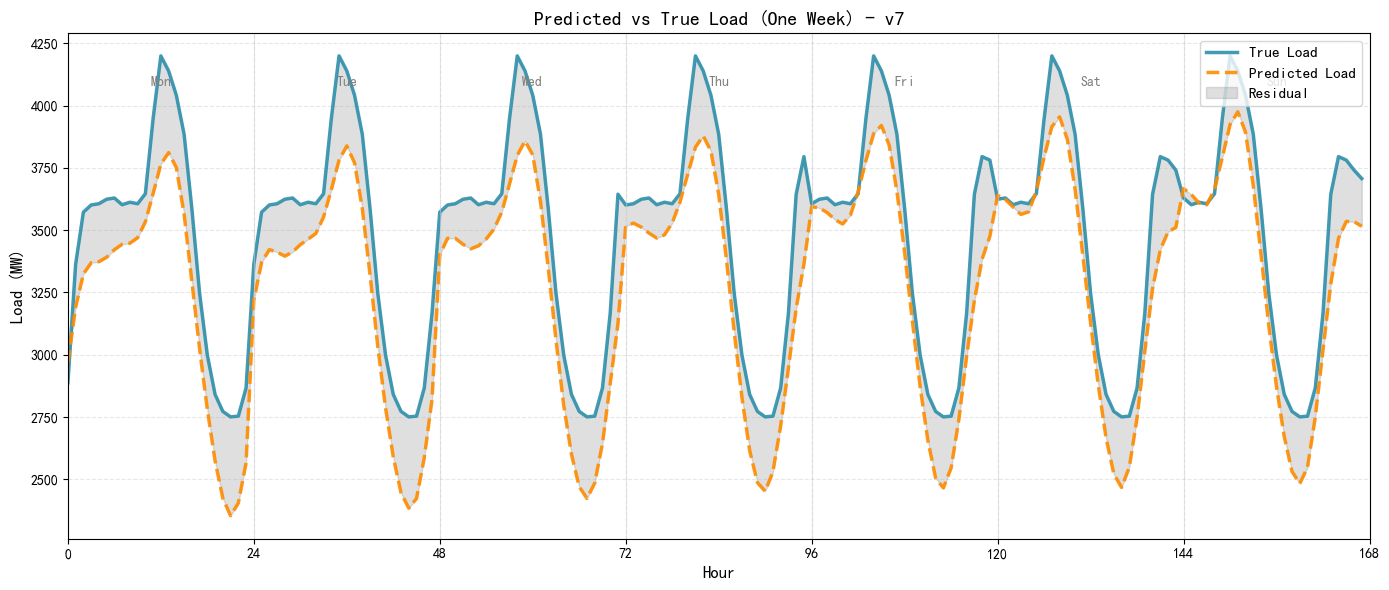

In [5]:
def plot_prediction_vs_true_week(preds, trues, residuals, save_dir='processed_data/visualization'):
    os.makedirs(save_dir, exist_ok=True)
    
    np.random.seed(42)
    start_idx = np.random.randint(0, len(preds) - 7)
    
    week_preds = []
    week_trues = []
    for i in range(7):
        idx = start_idx + i
        week_preds.extend(preds[idx])
        week_trues.extend(trues[idx])
    
    week_preds = np.array(week_preds)
    week_trues = np.array(week_trues)
    hours = np.arange(len(week_preds))
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.plot(hours, week_trues, label='True Load', 
            color='#2E8FAB', linewidth=2.5, alpha=0.9)
    ax.plot(hours, week_preds, label='Predicted Load', 
            color='#FF8C00', linewidth=2.5, alpha=0.9, linestyle='--')
    ax.fill_between(hours, week_trues, week_preds, 
                    alpha=0.25, color='gray', label='Residual')
    
    for day in range(1, 8):
        ax.axvline(x=day * 24, color='lightgray', linestyle='-', linewidth=0.8, alpha=0.5)
    
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    for i, day in enumerate(days):
        ax.text(i * 24 + 12, ax.get_ylim()[1] * 0.95, day, 
                ha='center', fontsize=10, color='gray', fontweight='bold')
    
    ax.set_xlabel('Hour', fontsize=12, fontweight='bold')
    ax.set_ylabel('Load (MW)', fontsize=12, fontweight='bold')
    ax.set_title('Predicted vs True Load (One Week) - v7', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(0, 168)
    ax.set_xticks(np.arange(0, 169, 24))
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, 'v7_fig2_prediction_week.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\u2713 图2已保存: {save_path}")
    return fig

plot_prediction_vs_true_week(preds, trues, residuals)

---
## 图 3：残差分布直方图

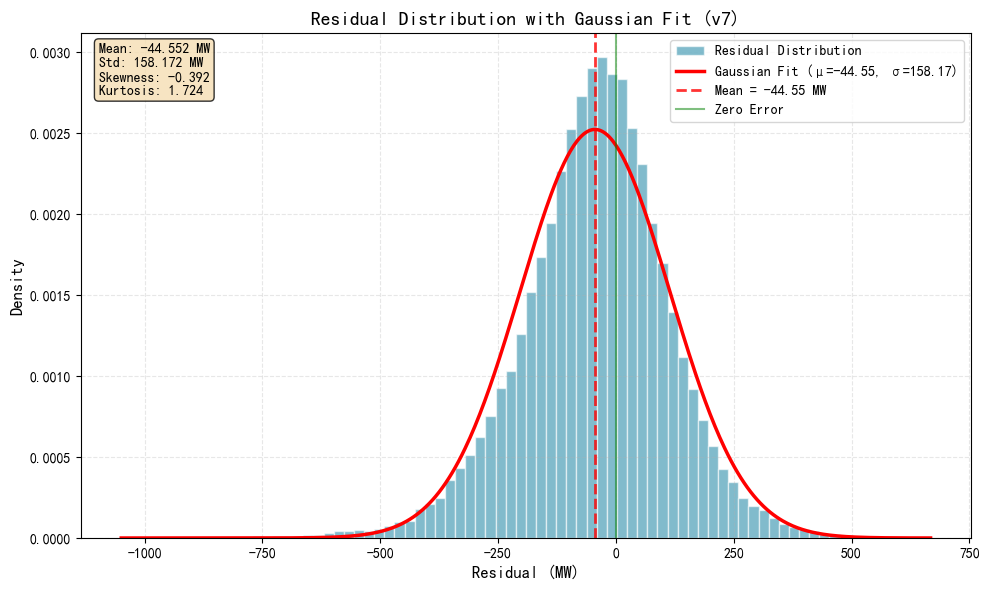

✓ 图3已保存: processed_data/visualization\v7_fig3_residual_histogram.png


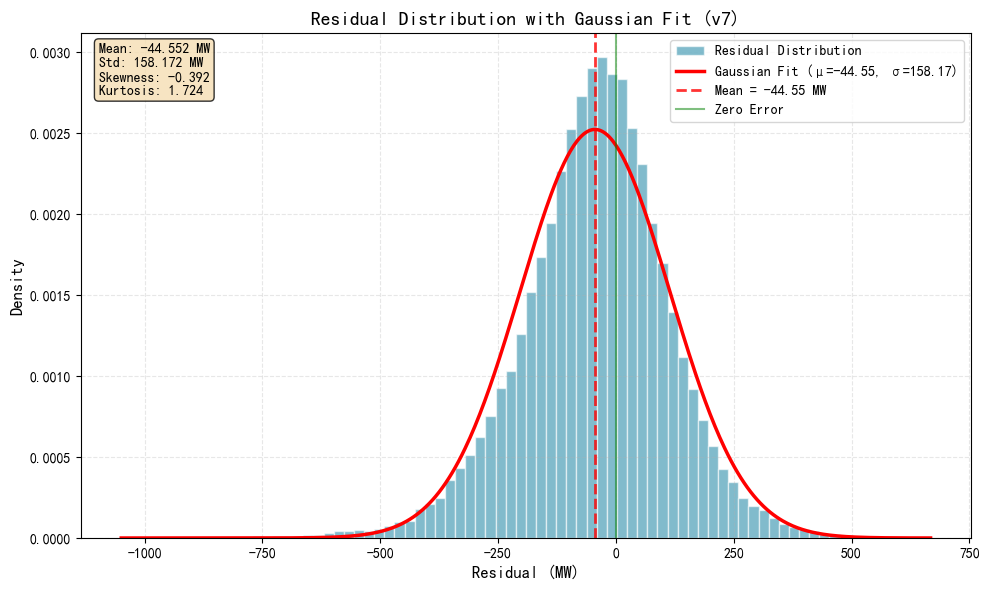

In [6]:
def plot_residual_histogram(residuals, save_dir='processed_data/visualization'):
    os.makedirs(save_dir, exist_ok=True)
    
    res_flat = residuals.reshape(-1)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    n, bins, patches = ax.hist(res_flat, bins=80, density=True, 
                               color='#2E8FAB', alpha=0.6, edgecolor='white', 
                               label='Residual Distribution')
    
    mu, std = norm.fit(res_flat)
    x = np.linspace(res_flat.min(), res_flat.max(), 500)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'r-', linewidth=2.5, label=f'Gaussian Fit (\u03bc={mu:.2f}, \u03c3={std:.2f})')
    
    ax.axvline(x=mu, color='red', linestyle='--', linewidth=2, alpha=0.8,
               label=f'Mean = {mu:.2f} MW')
    ax.axvline(x=0, color='green', linestyle='-', linewidth=1.5, alpha=0.5,
               label='Zero Error')
    
    textstr = f'Mean: {mu:.3f} MW\nStd: {std:.3f} MW\nSkewness: {stats.skew(res_flat):.3f}\nKurtosis: {stats.kurtosis(res_flat):.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    ax.set_xlabel('Residual (MW)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax.set_title('Residual Distribution with Gaussian Fit (v7)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, 'v7_fig3_residual_histogram.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\u2713 图3已保存: {save_path}")
    return fig

plot_residual_histogram(residuals)

---
## 图 4：残差 vs 时间散点图

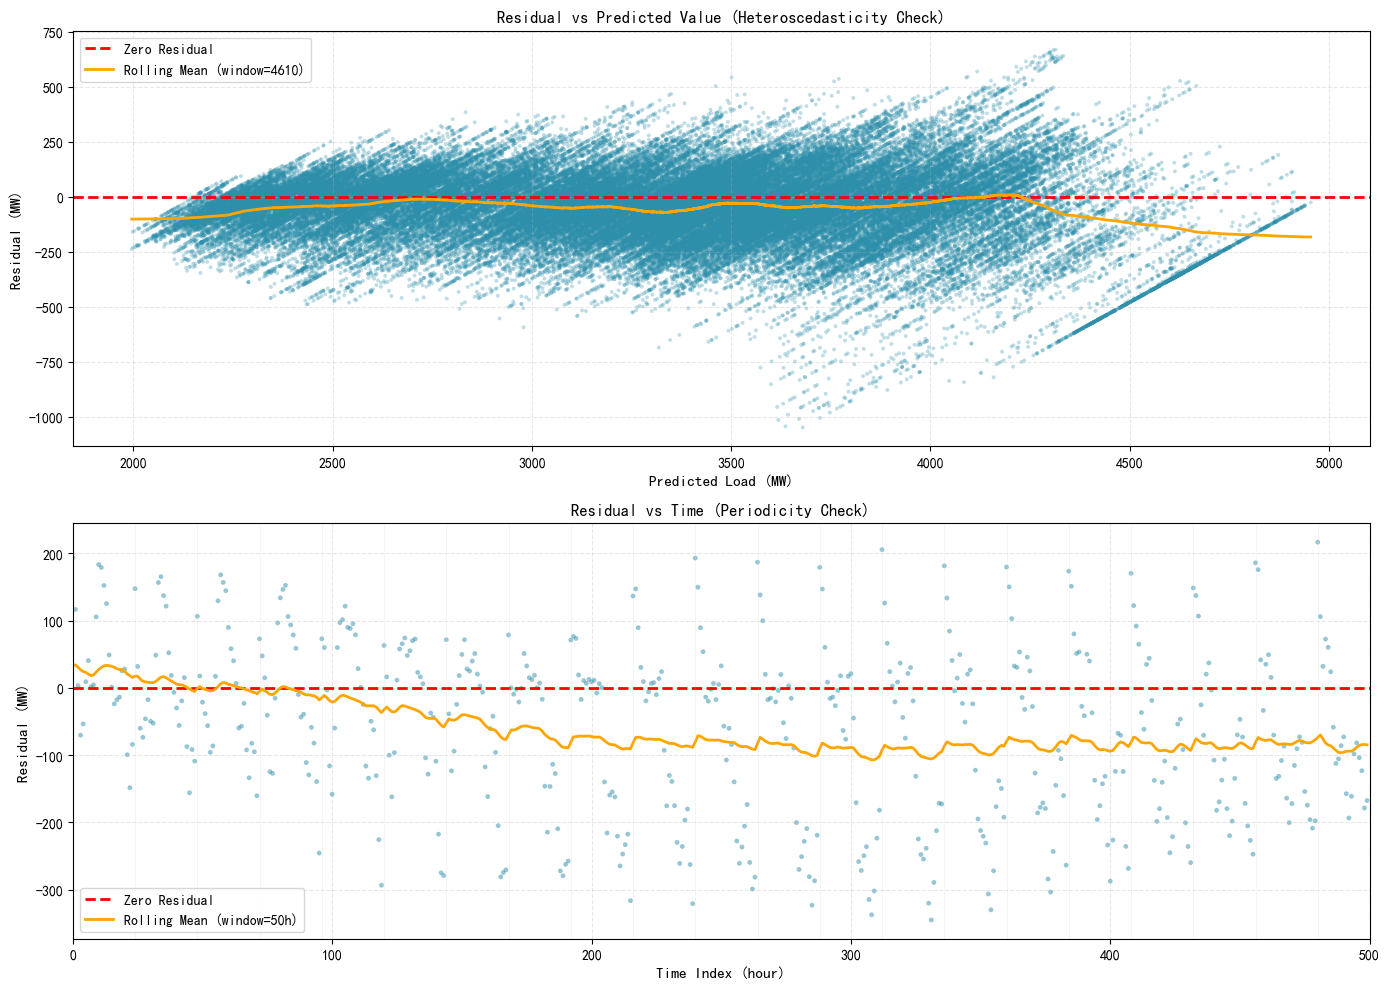

✓ 图4已保存: processed_data/visualization\v7_fig4_residual_vs_time.png


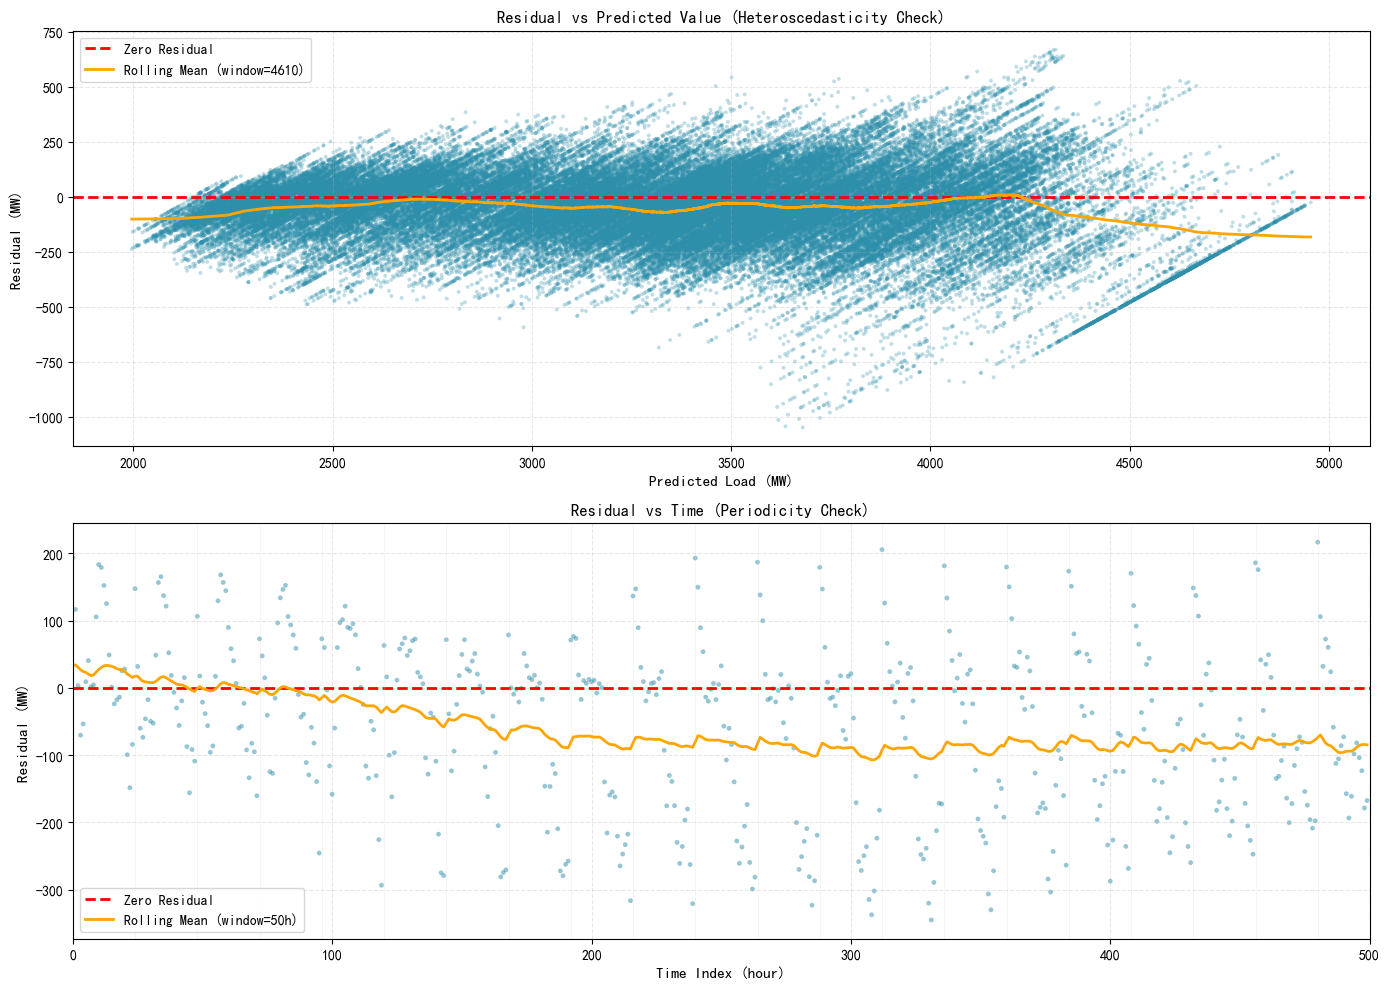

In [7]:
def plot_residual_vs_time(residuals, preds, trues, save_dir='processed_data/visualization'):
    os.makedirs(save_dir, exist_ok=True)
    
    res_flat = residuals.reshape(-1)
    pred_flat = preds.reshape(-1)
    true_flat = trues.reshape(-1)
    time_idx = np.arange(len(res_flat))
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    ax = axes[0]
    ax.scatter(pred_flat, res_flat, alpha=0.3, s=8, color='#2E8FAB', edgecolors='none')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
    
    sort_idx = np.argsort(pred_flat)
    window = max(len(pred_flat) // 20, 100)
    rolling_mean = pd.Series(res_flat[sort_idx]).rolling(window=window, center=True, min_periods=1).mean()
    ax.plot(pred_flat[sort_idx], rolling_mean, color='orange', linewidth=2, 
            label=f'Rolling Mean (window={window})')
    
    ax.set_xlabel('Predicted Load (MW)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Residual (MW)', fontsize=11, fontweight='bold')
    ax.set_title('Residual vs Predicted Value (Heteroscedasticity Check)', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    ax = axes[1]
    display_len = min(500, len(res_flat))
    ax.scatter(time_idx[:display_len], res_flat[:display_len], 
               alpha=0.5, s=12, color='#2E8FAB', edgecolors='none')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
    
    window_t = 50
    rolling_mean_t = pd.Series(res_flat[:display_len]).rolling(
        window=window_t, center=True, min_periods=1).mean()
    ax.plot(time_idx[:display_len], rolling_mean_t, color='orange', linewidth=2,
            label=f'Rolling Mean (window={window_t}h)')
    
    for h in range(0, display_len, 24):
        ax.axvline(x=h, color='lightgray', linestyle='-', linewidth=0.5, alpha=0.3)
    
    ax.set_xlabel('Time Index (hour)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Residual (MW)', fontsize=11, fontweight='bold')
    ax.set_title('Residual vs Time (Periodicity Check)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(0, display_len)
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, 'v7_fig4_residual_vs_time.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\u2713 图4已保存: {save_path}")
    return fig

plot_residual_vs_time(residuals, preds, trues)

---
## 图 5：注意力权重热力图

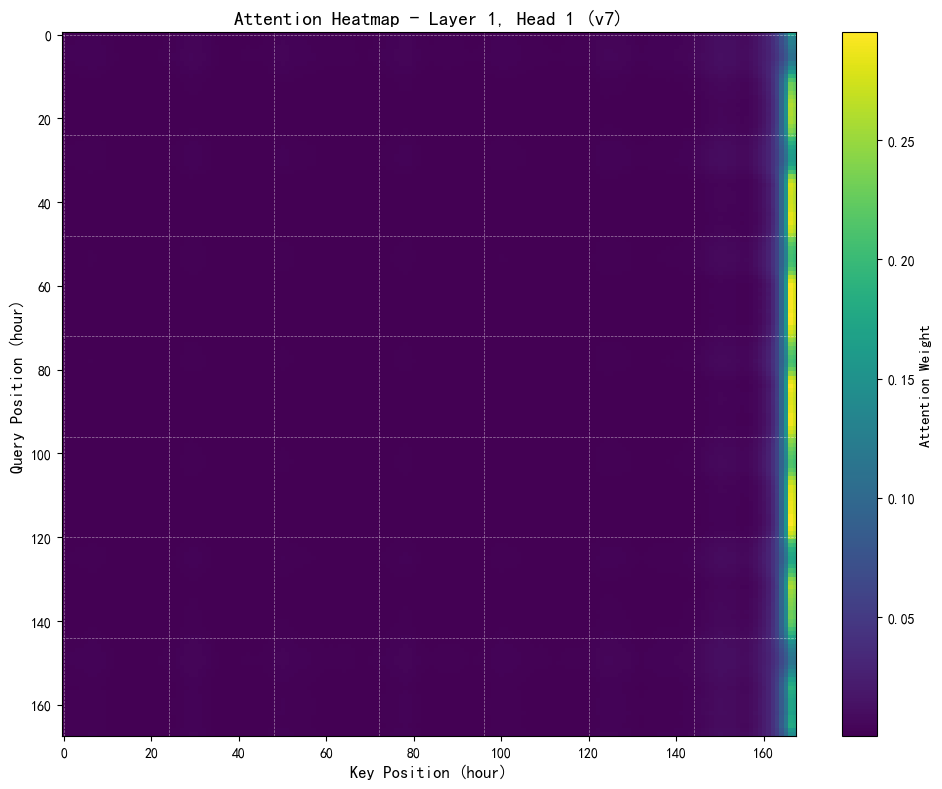

✓ 图5已保存: processed_data/visualization\v7_fig5_attention_heatmap.png


In [8]:
def plot_attention_heatmap(attn_weights, layer_idx, head_idx, save_dir='processed_data/visualization'):
    os.makedirs(save_dir, exist_ok=True)
    
    attn = attn_weights[0, head_idx]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(attn, cmap='viridis', aspect='auto')
    
    ax.set_xlabel('Key Position (hour)', fontsize=12)
    ax.set_ylabel('Query Position (hour)', fontsize=12)
    ax.set_title(f'Attention Heatmap - Layer {layer_idx+1}, Head {head_idx+1} (v7)', 
                 fontsize=14, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Attention Weight', fontsize=11)
    
    for h in range(0, attn.shape[0], 24):
        ax.axvline(x=h, color='white', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.axhline(y=h, color='white', linestyle='--', linewidth=0.5, alpha=0.5)
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, 'v7_fig5_attention_heatmap.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\u2713 图5已保存: {save_path}")
    return fig

if all_attn:
    plot_attention_heatmap(all_attn[0], layer_idx=0, head_idx=0)

---
## 第 6 步：生成汇总图（5张图拼成一张，适合 PPT）

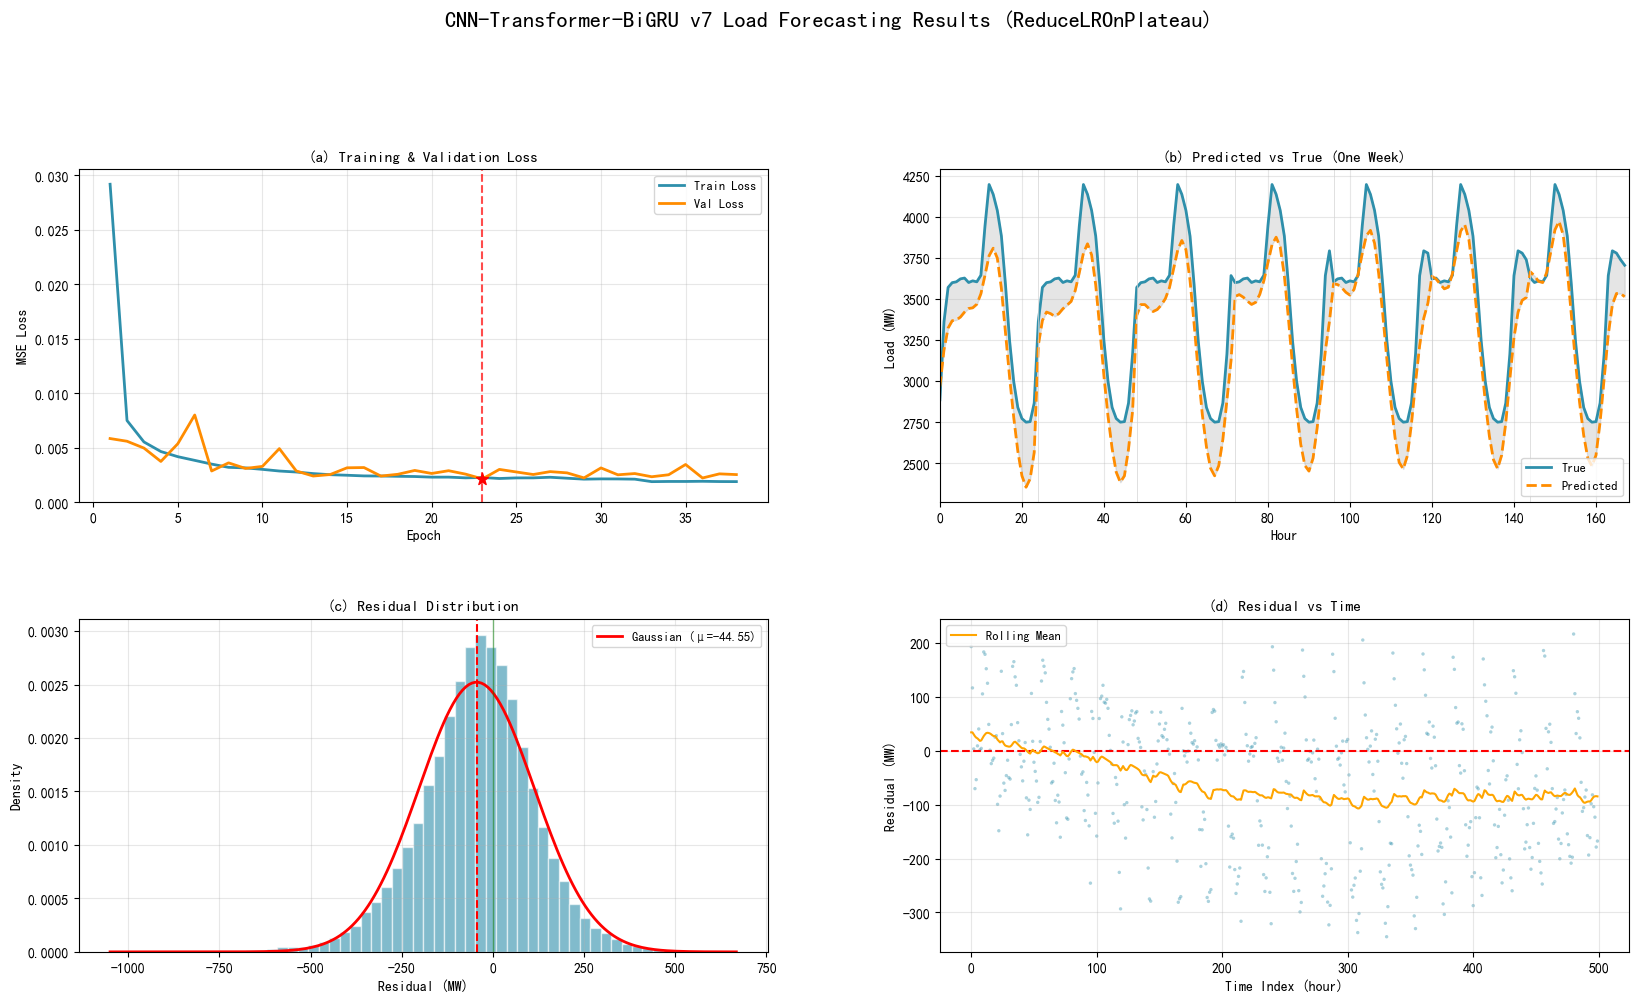

✓ 汇总图已保存: processed_data/visualization\v7_summary_all_figures.png


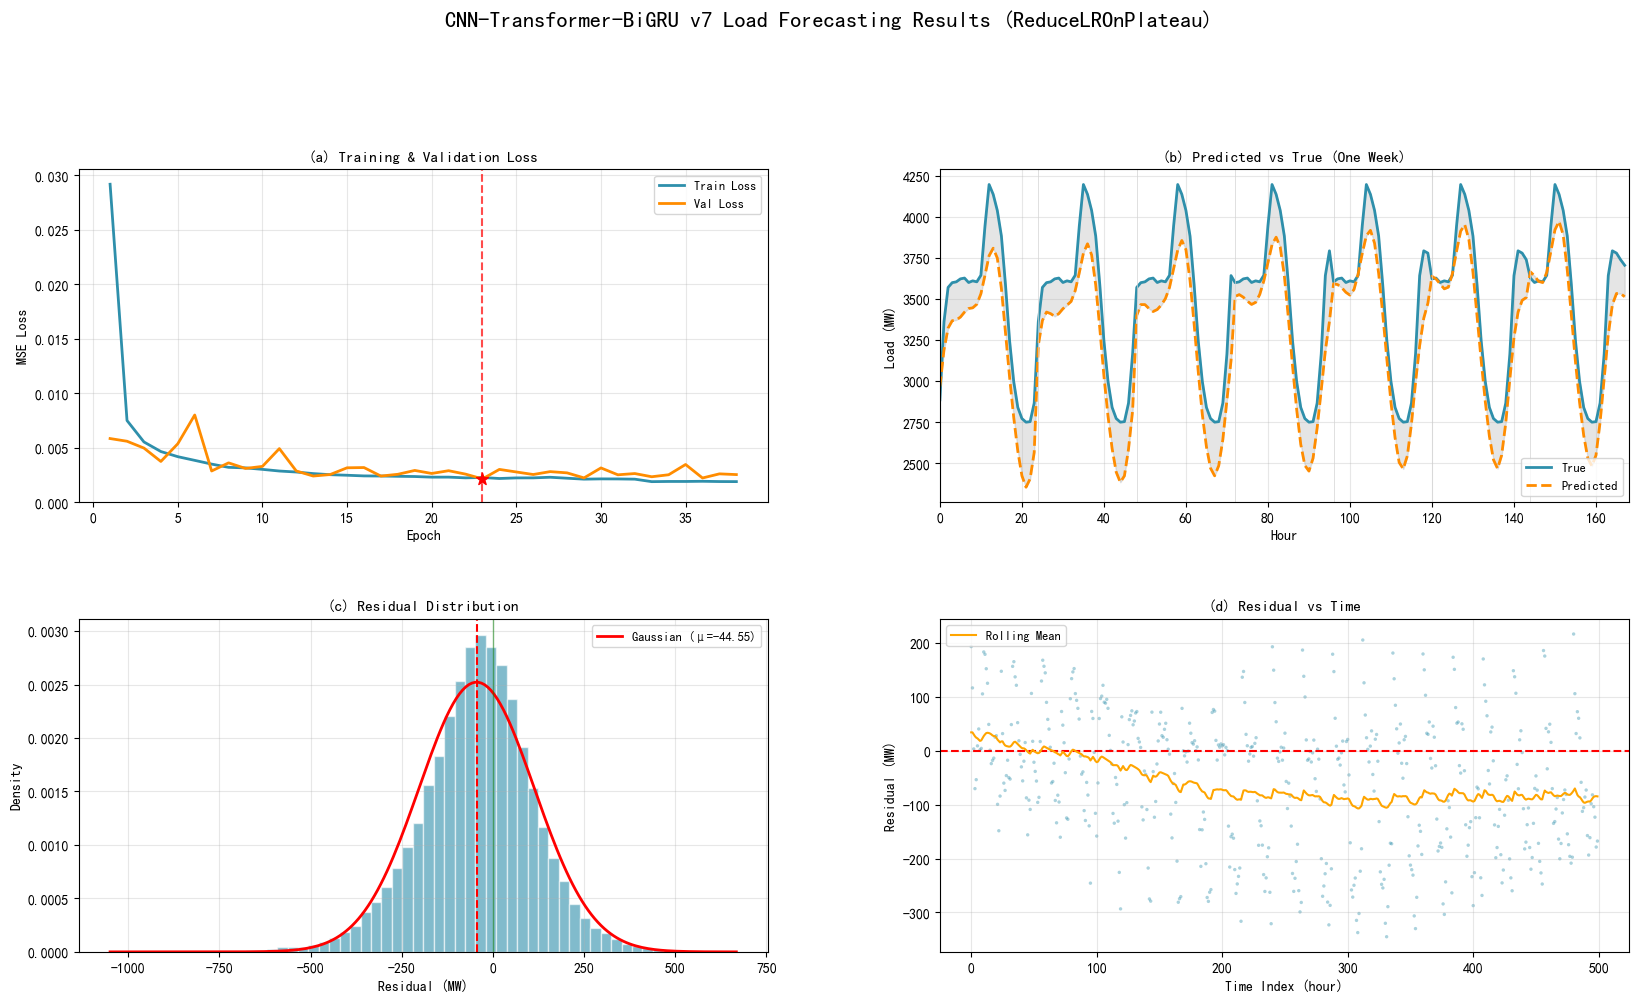

In [9]:
def generate_summary_figure(history, best_epoch, preds, trues, residuals, all_attn,
                            save_dir='processed_data/visualization'):
    os.makedirs(save_dir, exist_ok=True)
    
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.25)
    
    # 1. Loss 曲线
    ax1 = fig.add_subplot(gs[0, 0])
    if history:
        epochs = range(1, len(history['train_loss']) + 1)
        ax1.plot(epochs, history['train_loss'], color='#2E8FAB', linewidth=2, label='Train Loss')
        ax1.plot(epochs, history['val_loss'], color='#FF8C00', linewidth=2, label='Val Loss')
        ax1.axvline(x=best_epoch, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        ax1.scatter([best_epoch], [history['val_loss'][best_epoch - 1]], 
                   color='red', s=80, zorder=5, marker='*')
        ax1.set_ylim(bottom=0)
    ax1.set_xlabel('Epoch', fontsize=10)
    ax1.set_ylabel('MSE Loss', fontsize=10)
    ax1.set_title('(a) Training & Validation Loss', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 2. 预测 vs 真实值
    ax2 = fig.add_subplot(gs[0, 1])
    np.random.seed(42)
    start_idx = np.random.randint(0, len(preds) - 7)
    week_preds = np.concatenate([preds[start_idx + i] for i in range(7)])
    week_trues = np.concatenate([trues[start_idx + i] for i in range(7)])
    hours = np.arange(len(week_preds))
    ax2.plot(hours, week_trues, color='#2E8FAB', linewidth=2, label='True')
    ax2.plot(hours, week_preds, color='#FF8C00', linewidth=2, linestyle='--', label='Predicted')
    ax2.fill_between(hours, week_trues, week_preds, alpha=0.2, color='gray')
    for day in range(1, 8):
        ax2.axvline(x=day * 24, color='lightgray', linestyle='-', linewidth=0.5)
    ax2.set_xlabel('Hour', fontsize=10)
    ax2.set_ylabel('Load (MW)', fontsize=10)
    ax2.set_title('(b) Predicted vs True (One Week)', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 168)
    
    # 3. 残差直方图
    ax3 = fig.add_subplot(gs[1, 0])
    res_flat = residuals.reshape(-1)
    ax3.hist(res_flat, bins=60, density=True, color='#2E8FAB', alpha=0.6, edgecolor='white')
    mu, std = norm.fit(res_flat)
    x = np.linspace(res_flat.min(), res_flat.max(), 200)
    ax3.plot(x, norm.pdf(x, mu, std), 'r-', linewidth=2, label=f'Gaussian (\u03bc={mu:.2f})')
    ax3.axvline(x=mu, color='red', linestyle='--', linewidth=1.5)
    ax3.axvline(x=0, color='green', linestyle='-', linewidth=1, alpha=0.5)
    ax3.set_xlabel('Residual (MW)', fontsize=10)
    ax3.set_ylabel('Density', fontsize=10)
    ax3.set_title('(c) Residual Distribution', fontsize=11, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    # 4. 残差 vs 时间
    ax4 = fig.add_subplot(gs[1, 1])
    display_len = min(500, len(res_flat))
    time_idx = np.arange(display_len)
    ax4.scatter(time_idx, res_flat[:display_len], alpha=0.4, s=6, color='#2E8FAB', edgecolors='none')
    ax4.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    rolling_mean_t = pd.Series(res_flat[:display_len]).rolling(
        window=50, center=True, min_periods=1).mean()
    ax4.plot(time_idx, rolling_mean_t, color='orange', linewidth=1.5, label='Rolling Mean')
    ax4.set_xlabel('Time Index (hour)', fontsize=10)
    ax4.set_ylabel('Residual (MW)', fontsize=10)
    ax4.set_title('(d) Residual vs Time', fontsize=11, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # 总标题
    fig.suptitle('CNN-Transformer-BiGRU v7 Load Forecasting Results (ReduceLROnPlateau)', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    save_path = os.path.join(save_dir, 'v7_summary_all_figures.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\u2713 汇总图已保存: {save_path}")
    return fig

generate_summary_figure(history, best_epoch, preds, trues, residuals, all_attn)

---
## 输出文件清单

运行本 Notebook 后，`processed_data/visualization/` 目录下会生成：

| 文件名 | 说明 |
|:---|:---|
| `v7_fig1_loss_curve.png` | 训练/验证 Loss 曲线 |
| `v7_fig2_prediction_week.png` | 1周预测对比 |
| `v7_fig3_residual_histogram.png` | 残差分布直方图 |
| `v7_fig4_residual_vs_time.png` | 残差 vs 时间散点图 |
| `v7_fig5_attention_heatmap.png` | 注意力权重热力图 |
| `v7_summary_all_figures.png` | 5张图汇总（适合 PPT） |